In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive zmontowany!")

Mounted at /content/drive
Google Drive zmontowany!


In [7]:
!unzip 48.zip -d baza_48

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
  inflating: baza_48/48/train/surprised/im2350.png  
  inflating: baza_48/48/train/surprised/im2351.png  
  inflating: baza_48/48/train/surprised/im2352.png  
  inflating: baza_48/48/train/surprised/im2353.png  
  inflating: baza_48/48/train/surprised/im2354.png  
  inflating: baza_48/48/train/surprised/im2355.png  
  inflating: baza_48/48/train/surprised/im2356.png  
  inflating: baza_48/48/train/surprised/im2357.png  
  inflating: baza_48/48/train/surprised/im2358.png  
  inflating: baza_48/48/train/surprised/im2359.png  
  inflating: baza_48/48/train/surprised/im236.png  
  inflating: baza_48/48/train/surprised/im2360.png  
  inflating: baza_48/48/train/surprised/im2361.png  
  inflating: baza_48/48/train/surprised/im2362.png  
  inflating: baza_48/48/train/surprised/im2363.png  
  inflating: baza_48/48/train/surprised/im2364.png  
  inflating: baza_48/48/train/surprised/im2365.png  
  inflating: baza_48/48/train/surpr

In [8]:
train_path = 'baza_48/48/train'
test_path = 'baza_48/48/test'

Found 92019 images belonging to 7 classes.
Found 18141 images belonging to 7 classes.


/tmp/ipython-input-9-4029976401.py:49: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(75, 75, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2876/2876 ━━━━━━━━━━━━━━━━━━━━ 240s 77ms/step - accuracy: 0.3019 - loss: 1.7738 - learning_rate: 1.0000e-04
Epoch 2/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 206s 72ms/step - accuracy: 0.5045 - loss: 1.3105 - learning_rate: 1.0000e-04
Epoch 3/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 205s 71ms/step - accuracy: 0.5501 - loss: 1.1783 - learning_rate: 1.0000e-04
Epoch 4/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 211s 73ms/step - accuracy: 0.5837 - loss: 1.0976 - learning_rate: 1.0000e-04
Epoch 5/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 219s 76ms/step - accuracy: 0.6048 - loss: 1.0348 - learning_rate: 1.0000e-04
Epoch 6/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 202s 70ms/step - accuracy: 0.6260 - loss: 0.9880 - learning_rate: 1.0000e-04
Epoch 7/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 204s 71ms/step - accuracy: 0.6371 - loss: 0.9557 - learning_rate: 1.0000e-04
Epoch 8/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 204s 71ms/step - accuracy: 0.6487 - loss: 0.9131 - learning_rate: 1.0000e-04
Epoch 9/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 207s 72ms/step - 

567/567 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step
Raport klasyfikacji na zbiorze testowym:
              precision    recall  f1-score   support

       angry       0.69      0.61      0.65      2603
   disgusted       0.89      0.91      0.90       909
        fear       0.65      0.64      0.64      1711
       happy       0.78      0.80      0.79      4235
     neutral       0.57      0.62      0.60      3153
         sad       0.63      0.56      0.59      3181
   surprised       0.76      0.84      0.80      2349

    accuracy                           0.70     18141
   macro avg       0.71      0.71      0.71     18141
weighted avg       0.69      0.70      0.69     18141



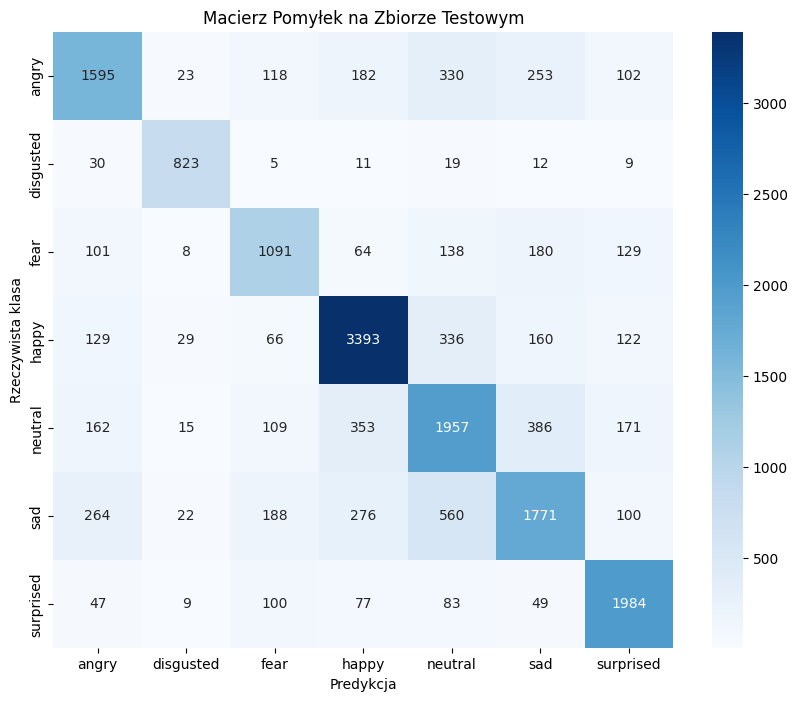

ModuleNotFoundError: No module named 'lime'

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix



# === Augmentacja danych ===
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_directory(
    train_path, target_size=(75, 75), batch_size=32,
    class_mode='categorical', shuffle=True
)

test_set = test_datagen.flow_from_directory(
    test_path, target_size=(75, 75), batch_size=32,
    class_mode='categorical', shuffle=False
)

# === Wagi klas ===
class_weights = dict(enumerate(compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_set.classes),
    y=train_set.classes
)))

# === Model ===
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(75, 75, 3))
for layer in base_model.layers[:-30]:
    layer.trainable = False
base_model.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_set.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# === Trening ===
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3)
history = model.fit(
    train_set,
    epochs=40,
    class_weight=class_weights,
    callbacks=[reduce_lr]
)

# === Zapis modelu ===
model.save("paulina_nowy_set_dodany_lime_confus_matrix_dla_test.h5")

# === Predykcja ===
Y_pred = model.predict(test_set)
y_pred = np.argmax(Y_pred, axis=1)

# === Etykiety klas ===
class_labels = test_set.class_indices
idx_to_label = {v: k for k, v in class_labels.items()}
target_names = [idx_to_label[i] for i in range(len(class_labels))]

# === Raport klasyfikacji ===
print("Raport klasyfikacji na zbiorze testowym:")
print(classification_report(test_set.classes, y_pred, target_names=target_names))

# === Macierz pomyłek ===
cm = confusion_matrix(test_set.classes, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista klasa')
plt.title('Macierz Pomyłek na Zbiorze Testowym')
plt.show()

# === LIME: interpretacja jednego obrazu ===
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Pobranie jednego obrazu z test_set
x_test, y_test = test_set[0]  # pierwszy batch
image = x_test[0]  # pierwszy obraz
true_class = np.argmax(y_test[0])

# Funkcja predykcyjna dla LIME
def predict_fn(images):
    return model.predict(images)

# Tworzenie wyjaśnienia LIME
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    image=image,
    classifier_fn=predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# Wizualizacja LIME
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    hide_rest=False,
    num_features=5,
    min_weight=0.0
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp, mask))
plt.title(f'LIME - prawdziwa klasa: {idx_to_label[true_class]}')
plt.axis('off')
plt.show()


In [4]:
!pip install lime


In [ ]:
model.save('paulina_nowy_set_dodany_lime_confus_matrix_dla_test.h5')

In [ ]:
from google.colab import files
files.download('/content/paulina_nowy_set_dodany_lime_confus_matrix_dla_test.h5')